# Assignment 2: Sentiment Classification with Neural Language Models

## Stage 2 - Hidden Test Evaluation

This notebook evaluates the model checkpoint submitted during Stage 1 on the hidden test set.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [2]:
hidden_test_df = pd.read_csv("hidden_test_with_labels.csv")

print("Hidden test shape:", hidden_test_df.shape)
display(hidden_test_df.head())

print("\nClass counts:")
print(hidden_test_df["label"].value_counts().sort_index())

Hidden test shape: (600, 5)


,id,text,label,label_name,source_file
0,neg_cv795_10291,"mr . bean , a bumbling security guard from eng...",0,negative,neg/cv795_10291.txt
1,neg_cv174_9735,"starship troopers is a bad movie . \ni mean , ...",0,negative,neg/cv174_9735.txt
2,pos_cv065_15248,"what a great film . \nwhat a stunning , touchi...",1,positive,pos/cv065_15248.txt
3,neg_cv076_26009,"susan granger's review of "" the watcher "" ( un...",0,negative,neg/cv076_26009.txt
4,neg_cv417_14653,the marvelous british actor derek jacobi stars...,0,negative,neg/cv417_14653.txt



Class counts:
label
0    300
1    300
Name: count, dtype: int64


In [3]:
CHECKPOINT_DIR = "model_checkpoint"

official_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR)

official_model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT_DIR
)

official_model = official_model.to(device)
official_model.eval()

print("Stage 1 checkpoint loaded successfully.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Stage 1 checkpoint loaded successfully.


In [4]:
def predict_review_with_chunks(
    text,
    model,
    tokenizer,
    max_length=512,
    stride=128
):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(outputs.logits, dim=1)

    average_probabilities = probabilities.mean(dim=0)

    prediction = int(torch.argmax(average_probabilities).item())

    return prediction, average_probabilities.cpu(), len(input_ids)

In [5]:
hidden_predictions = []

for _, row in tqdm(
    hidden_test_df.iterrows(),
    total=len(hidden_test_df),
    desc="Evaluating hidden test"
):
    prediction, _, _ = predict_review_with_chunks(
        row["text"],
        official_model,
        official_tokenizer
    )

    hidden_predictions.append(prediction)

print("Hidden test inference complete.")

Evaluating hidden test:   0%|          | 0/600 [00:00<?, ?it/s]

Hidden test inference complete.


In [6]:
hidden_labels = hidden_test_df["label"].astype(int).tolist()

hidden_accuracy = accuracy_score(
    hidden_labels,
    hidden_predictions
)

hidden_balanced_accuracy = balanced_accuracy_score(
    hidden_labels,
    hidden_predictions
)

hidden_macro_f1 = f1_score(
    hidden_labels,
    hidden_predictions,
    average="macro"
)

hidden_cm = confusion_matrix(
    hidden_labels,
    hidden_predictions
)

print("Hidden Test Results")
print("-------------------")
print("Accuracy:", round(hidden_accuracy * 100, 2), "%")
print("Balanced accuracy:", round(hidden_balanced_accuracy * 100, 2), "%")
print("Macro F1:", round(hidden_macro_f1, 4))

print("\nConfusion matrix:")
print(hidden_cm)

Hidden Test Results
-------------------
Accuracy: 86.67 %
Balanced accuracy: 86.67 %
Macro F1: 0.8657

Confusion matrix:
[[234  66]
 [ 14 286]]


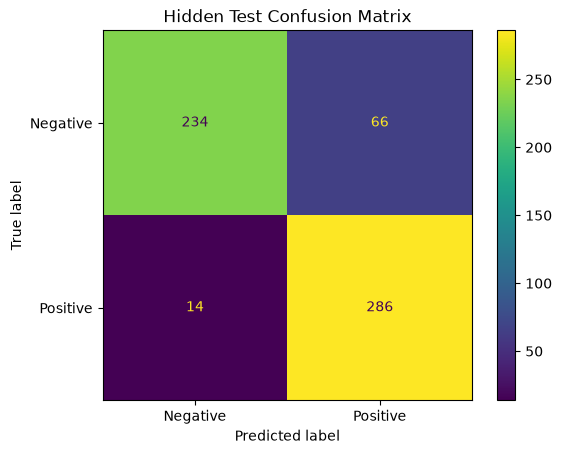

In [7]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=hidden_cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Hidden Test Confusion Matrix")
plt.show()

In [8]:
hidden_predictions_df = pd.DataFrame({
    "id": hidden_test_df["id"],
    "predicted_label": hidden_predictions
})

hidden_predictions_df.to_csv(
    "hidden_test_predictions.csv",
    index=False
)

display(hidden_predictions_df.head())

print(
    "Saved",
    len(hidden_predictions_df),
    "predictions to hidden_test_predictions.csv"
)

,id,predicted_label
0,neg_cv795_10291,0
1,neg_cv174_9735,0
2,pos_cv065_15248,1
3,neg_cv076_26009,0
4,neg_cv417_14653,0


Saved 600 predictions to hidden_test_predictions.csv


In [9]:
assert list(hidden_predictions_df.columns) == [
    "id",
    "predicted_label"
]

assert set(
    hidden_predictions_df["predicted_label"].unique()
).issubset({0, 1})

assert len(hidden_predictions_df) == len(hidden_test_df)

print("Prediction file format is correct.")

Prediction file format is correct.


## Hidden Test Results

The model achieved **86.67% accuracy** on the hidden test set.

- Accuracy: 86.67%
- Balanced Accuracy: 86.67%
- Macro F1: 0.8657
- Confusion Matrix: [[234, 66], [14, 286]]

The Stage 1 public test accuracy was **92.25%**, so the hidden test accuracy was **5.58 percentage points lower**.

The model performed much better on positive reviews than negative reviews. It correctly classified 286 out of 300 positive reviews, but only 234 out of 300 negative reviews. This shows that the model was more likely to incorrectly classify a negative review as positive.

One possible reason is that the original training data was imbalanced, with more positive reviews than negative reviews. Even though balanced sampling was used during training, the model may still have learned the positive class better. 

## What I Would Try With More Time

I would test a few ways to improve the model. I would try training with more negative examples so the model learns both classes more evenly. 

Another thing I would try is changing the chunking method for long reviews. Instead of giving every chunk the same importance, I could test different ways of combining the predictions from each chunk.

## Use of AI

I used ChatGPT as a support tool during Stage 2. It helped me understand the assignment requirements, organize the notebook, troubleshoot the evaluation code, and interpret the model results.

I ran the evaluation using the exact Stage 1 model checkpoint and verified the outputs myself.